# Séance 3 — Comparer les modèles de régression et introduire la validation croisée

## Fil rouge : Diabetes

Un modèle linéaire est-il nécessairement le meilleur modèle ?

Nous allons comparer plusieurs familles de modèles et comprendre pourquoi la validation croisée est nécessaire.

Objectifs :
- comparer plusieurs modèles ;
- comprendre le rôle du modèle de référence ;
- découvrir différents principes d'apprentissage ;
- introduire les hyperparamètres ;
- comprendre la validation croisée ;
- comparer moyenne et dispersion des scores ;
- effectuer une première sélection de modèle.

## 1. Pourquoi plusieurs modèles ?

La régression linéaire suppose une relation linéaire entre les variables et la cible.

Mais cette hypothèse peut être trop restrictive.

Nous allons considérer :

| Modèle | Idée principale |
|---|---|
| Dummy | référence naïve |
| Linear Regression | relation linéaire |
| Ridge | linéaire + pénalisation L2 |
| Lasso | linéaire + pénalisation L1 |
| ElasticNet | mélange L1/L2 |
| KNN | voisins proches |
| SVR | marge et noyau |
| Decision Tree | règles successives |
| Random Forest | ensemble d'arbres |
| Gradient Boosting | arbres construits successivement |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 2. Le modèle de référence : DummyRegressor

Un modèle complexe doit être comparé à quelque chose de simple.

`DummyRegressor()` peut simplement prédire la moyenne observée dans les données d'entraînement.

Il ne cherche pas de relation entre les variables et `target`.

S'il obtient un score comparable à un modèle complexe, cela signifie que le modèle complexe n'apporte pas grand-chose.

In [2]:
dummy = DummyRegressor()

scores_dummy = cross_val_score(
    dummy,
    Xtr,
    ytr,
    cv=5,
    scoring="r2"
)

scores_dummy

array([-0.0168316 , -0.00227983, -0.00356589, -0.00385568, -0.12581022])

## 3. Validation croisée : pourquoi ?

Supposons que nous fassions un seul découpage :

**80 % entraînement / 20 % test**

Le score dépend alors en partie des observations qui sont tombées dans chaque groupe.

La validation croisée permet de répéter l'évaluation sur plusieurs découpages.

### Validation croisée à 5 plis

On découpe les données en 5 groupes.

À chaque répétition :
- 4 groupes servent à l'apprentissage ;
- 1 groupe sert à la validation.

On obtient donc 5 scores.

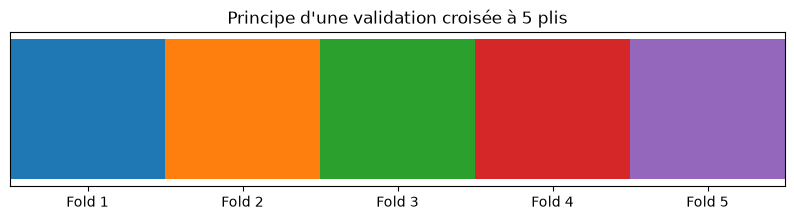

In [3]:
plt.figure(figsize=(10, 2))

for i in range(5):
    plt.barh(0, 1, left=i)

plt.xlim(0, 5)
plt.yticks([])
plt.xticks(np.arange(0.5, 5.5), ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"])
plt.title("Principe d'une validation croisée à 5 plis")
plt.show()

Le principe est :

**entraînement → validation → score**

puis on recommence avec une autre partie utilisée pour la validation.

Le score final est généralement résumé par :

$
\text{moyenne des scores}
$

et on peut également regarder :

$
\text{écart-type des scores}
$

## 4. Comparaison des modèles

Nous allons maintenant utiliser exactement la même procédure pour plusieurs modèles.

Le critère sera `R²`.

C'est important : pour comparer correctement les modèles, il faut utiliser **le même protocole et le même critère**.

In [5]:
modeles = {
    "Dummy": DummyRegressor(),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "KNN": KNeighborsRegressor(n_neighbors=10),
    "SVR": SVR(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

resultats = {}

for nom, modele in modeles.items():
    scores = cross_val_score(
        modele,
        Xtr,
        ytr,
        cv=5,
        scoring="r2"
    )

    resultats[nom] = {
        "R2_moyen": scores.mean(),
        "R2_ecart_type": scores.std()
    }

resultats_df = (
    pd.DataFrame(resultats)
    .T
    .sort_values("R2_moyen", ascending=False)
)

resultats_df

,R2_moyen,R2_ecart_type
Lasso,0.455510,0.118465
LinearRegression,0.449256,0.144095
RandomForest,0.390932,0.148784
Ridge,0.380242,0.076599
KNN,0.370056,0.108183
GradientBoosting,0.361768,0.183143
SVR,0.112206,0.017113
ElasticNet,0.073051,0.046279
Dummy,-0.030469,0.047964
DecisionTree,-0.132837,0.288489


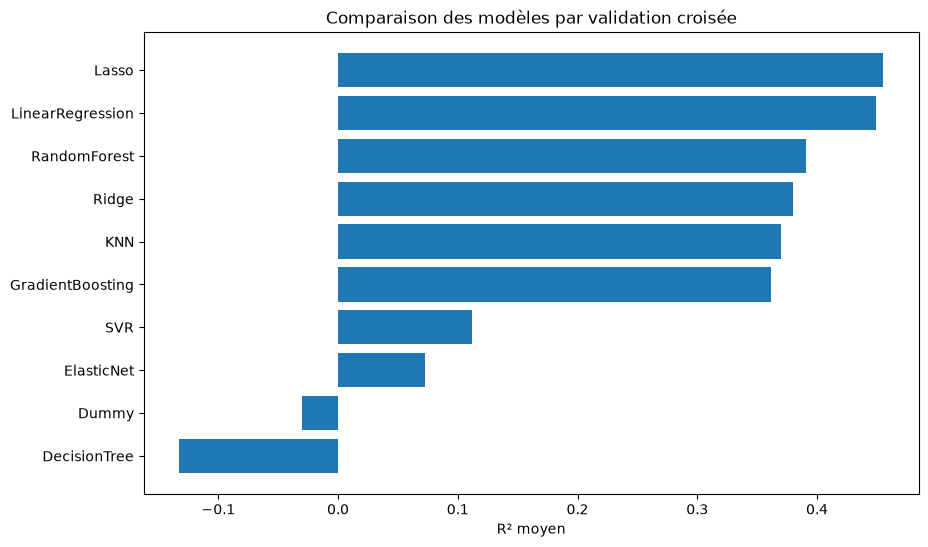

In [4]:
plt.figure(figsize=(10, 6))

plt.barh(
    resultats_df.index,
    resultats_df["R2_moyen"]
)

plt.xlabel("R² moyen")
plt.title("Comparaison des modèles par validation croisée")
plt.gca().invert_yaxis()
plt.show()

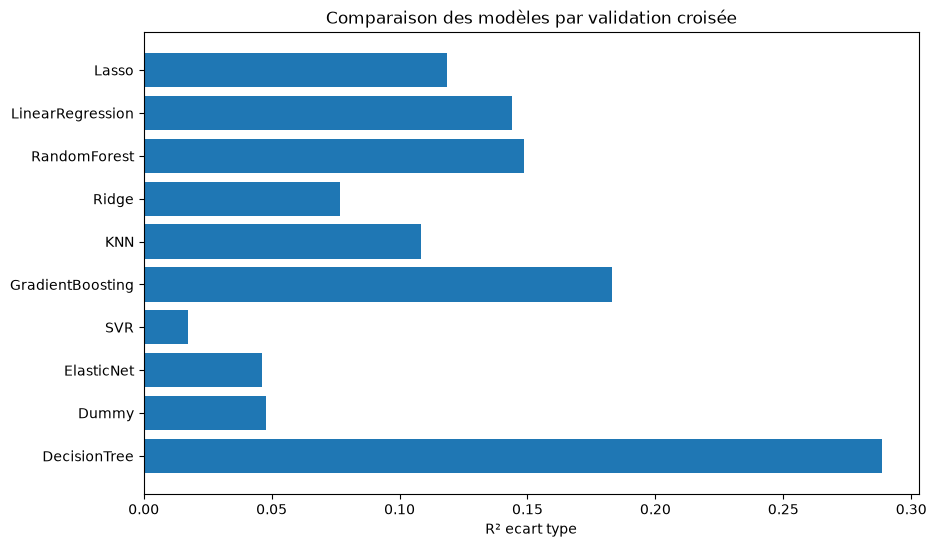

In [6]:
plt.figure(figsize=(10, 6))

plt.barh(
    resultats_df.index,
    resultats_df["R2_ecart_type"]
)

plt.xlabel("R² ecart type")
plt.title("Comparaison des modèles par validation croisée")
plt.gca().invert_yaxis()
plt.show()

### Question d'interprétation

1. Quels modèles semblent les meilleurs ?
2. Le DummyRegressor est-il nettement dépassé ?
3. Un modèle ayant un R² moyen légèrement supérieur est-il nécessairement préférable si son écart-type est beaucoup plus grand ?

In [7]:
resultats = {}
scores_modeles = {}

for nom, modele in modeles.items():
    scores = cross_val_score(
        modele,
        Xtr,
        ytr,
        cv=5,
        scoring="r2"
    )

    # On conserve les 5 scores pour les boxplots
    scores_modeles[nom] = scores

    # On conserve aussi moyenne et écart-type
    resultats[nom] = {
        "R2_moyen": scores.mean(),
        "R2_ecart_type": scores.std()
    }

resultats_df = (
    pd.DataFrame(resultats)
    .T
    .sort_values("R2_moyen", ascending=False)
)

resultats_df

,R2_moyen,R2_ecart_type
Lasso,0.455510,0.118465
LinearRegression,0.449256,0.144095
RandomForest,0.390932,0.148784
Ridge,0.380242,0.076599
KNN,0.370056,0.108183
GradientBoosting,0.361768,0.183143
SVR,0.112206,0.017113
ElasticNet,0.073051,0.046279
Dummy,-0.030469,0.047964
DecisionTree,-0.132837,0.288489


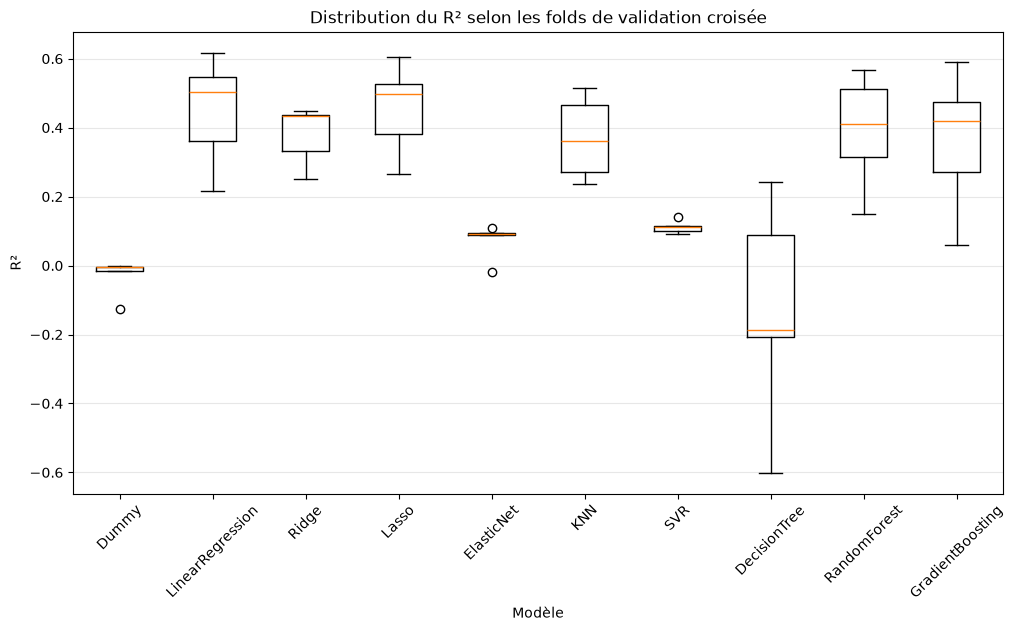

In [10]:
plt.figure(figsize=(12, 6))

plt.boxplot(
    list(scores_modeles.values()),
    tick_labels=list(scores_modeles.keys())
)

plt.ylabel("R²")
plt.xlabel("Modèle")
plt.title("Distribution du R² selon les folds de validation croisée")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

## 5. Comprendre Ridge, Lasso et ElasticNet

Ces trois modèles partent de la régression linéaire mais ajoutent une **pénalisation**.

### Ridge

$
MSE + \alpha\sum_j\beta_j^2
$

La norme L2 tend à réduire les coefficients.

### Lasso

$
MSE + \alpha\sum_j|\beta_j|
$

La norme L1 peut conduire certains coefficients exactement à 0.

### ElasticNet

Combine les deux pénalisations.

$
MSE+\alpha\left(\rho\sum_j|\beta_j|+(1-\rho)\sum_j\beta_j^2\right).
$

Ces pénalisations modifient le compromis entre ajustement aux données et complexité du modèle.

## 6. Les hyperparamètres

Un point essentiel :

### Paramètre

Appris par le modèle.

Exemple :
- les coefficients $\beta_j$ de la régression.

### Hyperparamètre

Choisi avant l'apprentissage.

Exemples :
- `alpha` pour Ridge/Lasso ;
- `n_neighbors` pour KNN ;
- profondeur d'un arbre ;
- nombre d'arbres dans une forêt ;
- nombre de neurones dans une couche.

La validation croisée peut être utilisée pour choisir les hyperparamètres.

## 7. KNN

Avec KNN, pour prédire une nouvelle observation, on cherche les observations les plus proches.

Avec :

```python
KNeighborsRegressor(n_neighbors=10)
```

on considère les **10 voisins les plus proches** et on utilise leurs valeurs de cible pour construire la prédiction.

Par défaut, la distance utilisée par `KNeighborsRegressor` est la **distance de Minkowski avec p=2**, c'est-à-dire la distance euclidienne.

$
d(x,z)=\left({\sum_j|x_j-z_j|^p}\right)^{1/p}
$

Comme les variables de Diabetes sont standardisées, les différentes variables sont ici sur des échelles comparables.

## 8. Effet de `n_neighbors`

- petit `k` : modèle très flexible, potentiellement très sensible aux observations ;
- grand `k` : prédictions plus lissées, modèle moins flexible.

Nous allons l'observer expérimentalement.

In [8]:
valeurs_k = [1, 3, 5, 10, 20, 40, 80]

resultats_knn = []

for k in valeurs_k:
    modele = KNeighborsRegressor(n_neighbors=k)

    scores = cross_val_score(
        modele,
        Xtr,
        ytr,
        cv=5,
        scoring="r2"
    )

    resultats_knn.append({
        "k": k,
        "R2_moyen": scores.mean(),
        "R2_ecart_type": scores.std()
    })

knn_df = pd.DataFrame(resultats_knn)

knn_df

,k,R2_moyen,R2_ecart_type
0,1,-0.098184,0.229779
1,3,0.242040,0.109146
2,5,0.317221,0.104040
3,10,0.370056,0.108183
4,20,0.401961,0.096144
5,40,0.395558,0.090165
6,80,0.358945,0.063880


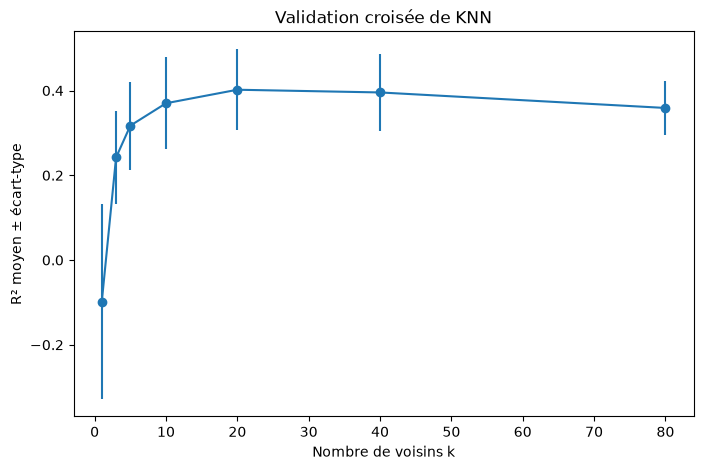

In [12]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    knn_df["k"],
    knn_df["R2_moyen"],
    yerr=knn_df["R2_ecart_type"],
    marker="o",
    linestyle="-"
)

plt.xlabel("Nombre de voisins k")
plt.ylabel("R² moyen ± écart-type")
plt.title("Validation croisée de KNN")
plt.show()

### Question d'interprétation

Quelle valeur de `k` semble donner le meilleur compromis ?

Observez également l'écart-type : les performances sont-elles très stables ?

## 9. Première idée du compromis biais / variance

Un modèle très flexible peut suivre très précisément les données d'entraînement.

Mais cela peut conduire au **surapprentissage**.

À l'inverse, un modèle trop simple peut être incapable de représenter la relation réelle.

On parle de compromis :

**biais ↔ variance**

KNN illustre très bien ce phénomène :
- `k` petit → forte flexibilité ;
- `k` grand → modèle plus lisse.

## 10. Sélection d'un modèle

La démarche correcte est :

1. on garde le jeu de test de côté ;
2. on utilise les données d'entraînement ;
3. on compare les modèles avec validation croisée ;
4. on choisit le modèle / les hyperparamètres ;
5. on réentraîne sur l'ensemble de `Xtr, ytr` ;
6. on évalue une seule fois sur le test.

In [9]:
# Exemple : choix automatique du meilleur modèle selon le R² moyen
meilleur_nom = resultats_df["R2_moyen"].idxmax()

print("Meilleur modèle selon la validation croisée :", meilleur_nom)
print(resultats_df.loc[meilleur_nom])

Meilleur modèle selon la validation croisée : Lasso
R2_moyen         0.455510
R2_ecart_type    0.118465
Name: Lasso, dtype: float64


In [10]:
meilleur_modele = modeles[meilleur_nom]

meilleur_modele.fit(Xtr, ytr)

r2_train = meilleur_modele.score(Xtr, ytr)
r2_test = meilleur_modele.score(Xte, yte)

print("R² entraînement :", round(r2_train, 3))
print("R² test :", round(r2_test, 3))

R² entraînement : 0.517
R² test : 0.472


### Question finale

Comparez :

- R² moyen en validation croisée ;
- R² obtenu sur le test.

Pourquoi ces deux nombres ne sont-ils pas nécessairement identiques ?

Que faudrait-il surveiller si le score de validation croisée était très élevé mais le score test beaucoup plus faible ?

# Bilan de la séance

Nous avons vu que comparer des modèles ne consiste pas simplement à entraîner plusieurs algorithmes et à regarder un score.

Il faut :

**1. définir un critère**

Ici : R².

**2. utiliser un protocole comparable**

Ici : validation croisée à 5 plis.

**3. tenir compte de la variabilité**

Moyenne + écart-type.

**4. distinguer paramètres et hyperparamètres**

**5. garder un jeu de test indépendant**

La prochaine étape sera d'aller plus loin dans le choix des hyperparamètres et dans la préparation des données.